In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
  OneHotEncoder,
  StandardScaler,
  KBinsDiscretizer
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Preparing the Housing Prices Dataset

## Dataset Description

Columns and their data types:
- longitude: continuous numerical
- latitude: continuous numerical
- housing_median_age: integer, needs to be categorized due to a value cap in the data collection
- total_rooms: integer
- total_bedrooms: integer
- population: integer
- households: integer
- median_income: continuous, needs to be categorized due to value cap in the data collection
- ocean_proximity: non-linear categorical
- median_house_value: continuous, needs to be categorized due to value cap in the data collection\*

\* Since the median_house_value is the target for the model's predictions, this one will not be categorized, we'll simply accept the model's incapacity to estimate accurately the value of highly valued housing

In [3]:
df = pd.read_csv("housing.csv")
df.dropna(inplace=True)
df_x = df.drop(columns=["median_house_value"])
df_y = df[["median_house_value"]]

numeric_columns = [
  "longitude",
  "latitude",
  "total_rooms",
  "total_bedrooms",
  "population",
  "households",
]

categorical_columns = [
  "ocean_proximity"
]

capped_columns = [
  "housing_median_age",
  "median_income",
]

In [6]:
# Split training and testing dataset
train_x, test_x, train_y, test_y = train_test_split(df_x, df_y, test_size=0.1)

# Preprocessing
preprocessor = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), numeric_columns),
    ("cat", OneHotEncoder(drop="first"), categorical_columns),
    ("bin", KBinsDiscretizer(n_bins=10, encode="onehot-dense", strategy="quantile"), capped_columns)
  ]
)

output_preprocessor = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), ["median_house_value"]) 
  ]
)

original_train_x = train_x.copy()
original_test_x = test_x.copy()
original_train_y = train_y.copy()
original_test_y = test_y.copy()

preprocessor.fit(train_x)
train_x = preprocessor.transform(train_x)
test_x = preprocessor.transform(test_x)

output_preprocessor.fit(train_y)
train_y = output_preprocessor.transform(train_y)
test_y = output_preprocessor.transform(test_y)

/usr/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


# Linear Regression

In [7]:
class LinearRegression:
  def __init__(
    self,
    input_size: int
  ):
    self.weights: np.ndarray = np.random.rand(input_size)
    self.bias: float = np.random.rand(1)[0]

  def loss(self, output: np.ndarray, expected: np.ndarray) -> float:
    return np.sum((output-expected)**2)/2

  def fit(self, train_x, train_y, verbose=False, epochs: int=100, training_step: float=0.01, plot: bool=False):
    losses = []
    for epoch in range(epochs):
      loss = 0
      step = np.zeros(self.weights.shape[0])
      bias_step = 0
      for input, expected in zip(train_x, train_y):
        output = self.predict(input)
        loss += self.loss(output, expected)
        step += training_step*(output-expected)*input
        bias_step += training_step*(output-expected)
      loss /= len(train_x)
      self.weights -= step/len(train_x)
      self.bias -= bias_step/len(train_x)
      losses.append(loss)
      if verbose: print(f"Epoch {epoch}: loss: {loss}")
    if plot:
      plt.plot(losses)

  def predict(self, input: np.ndarray):
    return self.weights @ input + self.bias

  def test(self, test_x, test_y):
    loss = 0
    for input, expected in zip(test_x, test_y):
      loss += self.loss(self.predict(input), expected)
    loss /= len(test_x)
    print(f"Tested loss: {loss}")

## Testing the implementation

Tested loss: 0.1844964448172081


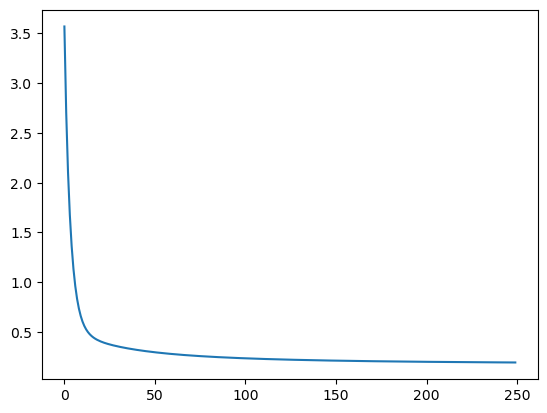

In [9]:
model = LinearRegression(train_x[0].shape[0])
model.fit(train_x, train_y, verbose=False, epochs=250, training_step=0.1, plot=True)
model.test(test_x, test_y)

## Using Scikit Learn to compare results

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
  ("preprocessing", preprocessor),
  ("regressor", LinearRegression())
])

# Here, train_y is used instead of original_train_y since I'd like the results to be normalized, in order to make result comparison easier
pipeline.fit(original_train_x, train_y)

/usr/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [21]:
# Checking the loss on my own since I can't find sklearn evaluation's methods
y_pred = pipeline.predict(original_test_x)
np.sum(((y_pred-test_y))**2)/test_x.shape[0]

np.float64(0.35343386948748307)

Even sklearn's implementation doesn't seem to be giving a very good of a result. Are we doomed, is the problem's nature just not linear?

# Logistic Regression

In [ ]:
class LogisticRegression:
  def __init__(
    self,
    input_size: int
  ):
    self.weights: np.ndarray = np.random.rand(input_size)
    self.bias: float = np.random.rand(1)[0]

  def loss(self, output: np.ndarray, expected: np.ndarray) -> float:
    return np.sum((output-expected)**2)/2

  @classmethod
  def sigmoid(cls, x): return 1/(1+np.exp(-x**2))

  @classmethod
  def sigmoid_prime(cls, x): return LogisticRegression.sigmoid(x)*(1-LogisticRegression.sigmoid(x))

  def fit(self, train_x, train_y, verbose=False, epochs: int=100, training_step: float=0.01, plot: bool=False):
    losses = []
    for epoch in range(epochs):
      loss = 0
      step = np.zeros(self.weights.shape[0])
      bias_step = 0
      for input, expected in zip(train_x, train_y):
        output = self.predict(input)
        loss += self.loss(output, expected)
        step += training_step*(output-expected)*input
        bias_step += training_step*(output-expected)
      loss /= len(train_x)
      self.weights -= step/len(train_x)
      self.bias -= bias_step/len(train_x)
      losses.append(loss)
      if verbose: print(f"Epoch {epoch}: loss: {loss}")
    if plot:
      plt.plot(losses)

  def predict(self, input: np.ndarray):
    return self.sigmoid(self.weights @ input + self.bias)

  def test(self, test_x, test_y):
    loss = 0
    for input, expected in zip(test_x, test_y):
      loss += self.loss(self.predict(input), expected)
    loss /= len(test_x)
    print(f"Tested loss: {loss}")

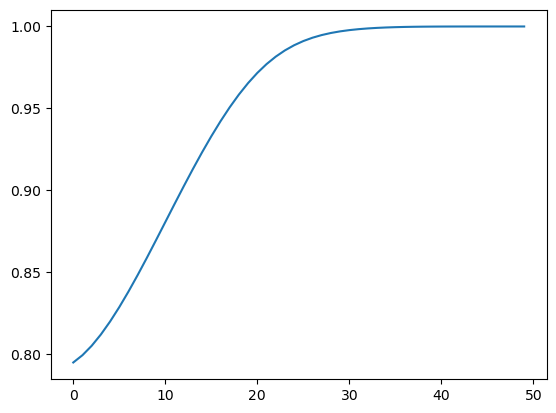

In [35]:
model = LogisticRegression(train_x.shape[1])
model.fit(train_x, train_y, plot=True, training_step=0.1, epochs=50)

# Locally Weighted Linear Regression

In [ ]:
class LocallyWeightedRegression:
  def __init__(self, tau: float = 0.5):
    self.tau = tau
    self.train_x = None
    self.train_y = None

  def loss(self, output: float, expected: float) -> float:
    return ((output - expected) ** 2) / 2

  def fit(self, train_x, train_y):
    self.train_x = train_x
    self.train_y = train_y

  def _weights(self, query: np.ndarray):
    m = self.train_x.shape[0]
    W = np.zeros((m, m))

    for i in range(m):
      diff = self.train_x[i] - query
      W[i, i] = np.exp(-(diff @ diff) / (2 * self.tau**2))

    return W

  def predict(self, query: np.ndarray):
    X = self.train_x
    y = self.train_y

    # bias
    X_bias = np.c_[np.ones(X.shape[0]), X]
    query_bias = np.concatenate(([1], query))

    W = self._weights(query)

    XT_W = X_bias.T @ W
    theta = np.linalg.pinv(XT_W @ X_bias) @ XT_W @ y

    return query_bias @ theta

  def test(self, test_x, test_y, plot=False):
    losses = []
    preds = []

    for input, expected in zip(test_x, test_y):
      pred = self.predict(input)
      preds.append(pred)

      loss = self.loss(pred, expected)
      losses.append(loss)

    mean_loss = np.mean(losses)
    print(f"Tested loss: {mean_loss}")

    if plot:
      plt.plot(losses)

    return preds

Tested loss: 0.10665331633516088


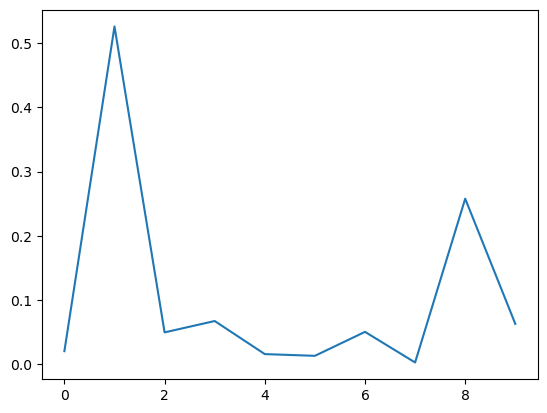

In [25]:
model = LocallyWeightedRegression(tau=5)
model.fit(train_x, train_y)
output = model.test(train_x[:10], train_y[:10], plot=True)

Scikit Learn doesn't offer an implementation of LWR, so we'll just trust the observed loss for each entry makes sense.